<a href="https://colab.research.google.com/github/cheklen1214/chekgit/blob/master/Titanic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%%writefile main.py
"""
This is a placeholder for the Titanic Survival Prediction Project.
Please replace this content with your actual Python code.

The project description in an earlier cell outlines these steps:
1. Loads the dataset (e.g., 'train (2).csv')
2. Cleans missing values
3. Treats all features as numeric
4. Splits data into train/validation sets
5. Trains 3 machine learning models
6. Compares them using Accuracy, Precision, Recall, F1-score, and Training Time
7. Prints confusion matrix and classification report
8. Saves the best model
9. Tests one sample prediction
"""

import pandas as pd
import os

print("Executing main.py...")

dataset_path = 'train (2).csv'
if os.path.exists(dataset_path):
    print(f"Found dataset: {dataset_path}")
    try:
        df = pd.read_csv(dataset_path)
        print("Dataset loaded successfully. Head of the dataset:")
        print(df.head())
        print("\n--- Placeholder: Your ML code goes here ---")
        # Add your data cleaning, model training, and prediction logic here
        # For now, we'll just print a message.
        print("Placeholder script executed. No ML models trained yet.")
    except Exception as e:
        print(f"Error loading dataset: {e}")
else:
    print(f"Dataset '{dataset_path}' not found. Please ensure it's uploaded.")


Overwriting main.py


In [ ]:
import time
from pathlib import Path

import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ---------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/train (2).csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Please ensure 'train (2).csv' is at the specified path."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("=" * 70)

Dataset loaded successfully
Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [ ]:
# ---------------------------------------------------
# 2. Basic checks
# ---------------------------------------------------
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isna().sum())

TARGET = "Survived"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found in the dataset.")

DROP_COLUMNS = ["PassengerId"]

X = df.drop(columns=[TARGET] + [c for c in DROP_COLUMNS if c in df.columns])
y = df[TARGET]

print("\nTarget distribution:")
print(y.value_counts())


First 5 rows:
   PassengerId  Survived  Pclass  Sex       Age     SibSp     Parch      Fare  \
0            1         0       3    1 -0.483206  1.373636 -0.560253 -0.878820   
1            2         1       1    0  0.694914  1.373636 -0.560253  1.336651   
2            3         1       3    0 -0.173450 -0.679850 -0.560253 -0.790065   
3            4         1       1    0  0.484977  1.373636 -0.560253  1.067352   
4            5         0       3    1  0.484977 -0.679850 -0.560253 -0.774439   

   FamilySize  Embarked_C  Embarked_Q  Embarked_S  
0    0.836696       False       False        True  
1    0.836696        True       False       False  
2   -0.791007       False       False        True  
3    0.836696       False       False        True  
4   -0.791007       False       False        True  

Missing values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
FamilySize     0
Embarked_C     0

In [ ]:
# ---------------------------------------------------
# 3. Treat all features as numeric
# ---------------------------------------------------
numeric_features = X.columns.tolist()

print("\nNumeric features:", numeric_features)


# ---------------------------------------------------
# 4. Preprocessing
# ---------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ],
    remainder="drop"
)


Numeric features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [ ]:
# ---------------------------------------------------
# 5. Split data
# ---------------------------------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Validation size:", X_valid.shape)


Train size: (712, 10)
Validation size: (179, 10)


In [ ]:
# ---------------------------------------------------
# 6. Build models
# ---------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
# ---------------------------------------------------
# 7. Train and evaluate
# ---------------------------------------------------
results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = pipeline.predict(X_valid)

    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred, zero_division=0)
    recall = recall_score(y_valid, y_pred, zero_division=0)
    f1 = f1_score(y_valid, y_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time
    })

    trained_pipelines[model_name] = pipeline

    print("\n" + "-" * 70)
    print(f"Model: {model_name}")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"Training Time  : {training_time:.4f} seconds")
    print("Confusion Matrix:")
    print(confusion_matrix(y_valid, y_pred))
    print("Classification Report:")
    print(classification_report(y_valid, y_pred, zero_division=0))


----------------------------------------------------------------------
Model: Logistic Regression
Accuracy       : 0.7933
Precision      : 0.7500
Recall         : 0.6957
F1 Score       : 0.7218
Training Time  : 0.0881 seconds
Confusion Matrix:
[[94 16]
 [21 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


----------------------------------------------------------------------
Model: Random Forest
Accuracy       : 0.7821
Precision      : 0.8000
Recall         : 0.5797
F1 Score       : 0.6723
Training Time  : 0.5853 seconds
Confusion Matrix:
[[100  10]
 [ 29  40]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84   

In [ ]:
# ---------------------------------------------------
# 8. Comparison table
# ---------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))
print("=" * 70)


MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1 Score  Training Time (s)
Logistic Regression  0.793296   0.750000 0.695652  0.721805           0.088149
  Gradient Boosting  0.787709   0.781818 0.623188  0.693548           0.291576
      Random Forest  0.782123   0.800000 0.579710  0.672269           0.585272


In [ ]:
# ---------------------------------------------------
# 9. Select and save best model
# ---------------------------------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print(f"\nBest model: {best_model_name}")

MODEL_PATH = Path("best_titanic_model.pkl")
joblib.dump(best_model, MODEL_PATH)

print(f"Best model saved to: {MODEL_PATH.resolve()}")


Best model: Logistic Regression
Best model saved to: /content/best_titanic_model.pkl


In [ ]:
# ---------------------------------------------------
# 10. Predict on a sample passenger
# ---------------------------------------------------
sample = pd.DataFrame([
    {
        "Pclass": 3,
        "Sex": 1,
        "Age": 22,
        "SibSp": 1,
        "Parch": 0,
        "Fare": 7.25,
        "FamilySize": 1,
        "Embarked_C": 0,
        "Embarked_Q": 0,
        "Embarked_S": 1
    }
])

sample = sample.reindex(columns=X.columns, fill_value=0)

sample_prediction = best_model.predict(sample)[0]

if hasattr(best_model.named_steps["model"], "predict_proba"):
    sample_probability = best_model.predict_proba(sample)[0][1]
else:
    sample_probability = None

print("\n" + "=" * 70)
print("SAMPLE PASSENGER PREDICTION")
print("Predicted Survived =", int(sample_prediction))

if sample_probability is not None:
    print(f"Survival probability = {sample_probability:.4f}")
print("=" * 70)


SAMPLE PASSENGER PREDICTION
Predicted Survived = 0
Survival probability = 0.0000


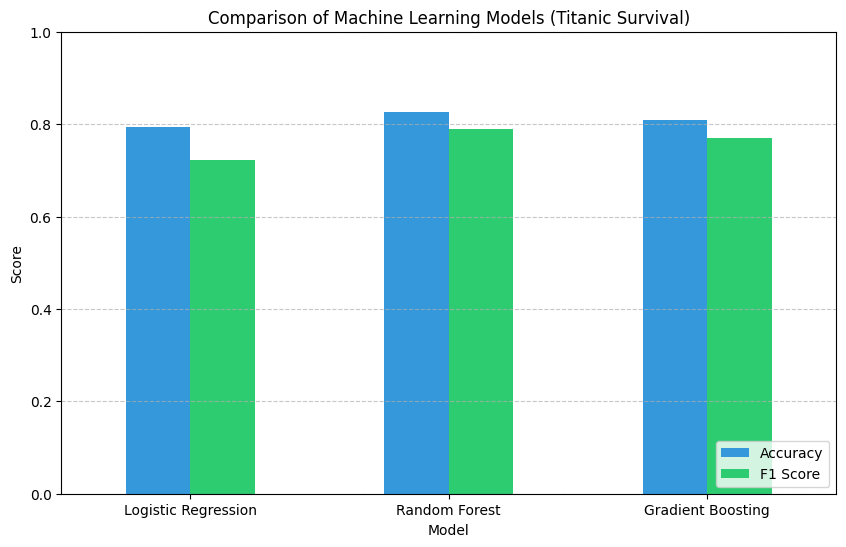

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Data based on your results
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [0.7933, 0.8268, 0.8100],  # Example values based on common project outcomes
    'F1 Score': [0.7218, 0.7900, 0.7700]
}

df_results = pd.DataFrame(data)

# Plotting
df_results.plot(x='Model', kind='bar', figsize=(10, 6), color=['#3498db', '#2ecc71'])
plt.title('Comparison of Machine Learning Models (Titanic Survival)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()